In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import plotly.graph_objects as go
from matplotlib.animation import FuncAnimation
import matplotlib


We solve the following differential equation:
$$ m\ddot{\vec{r}} = -\xi\dot{\vec{r}}-\nabla U(\vec{r}) + \vec{F}_\mathrm{ext}.$$

For the profile of the bowl we consider a quadratic function
$$ U(\vec{r}) = U_0 r^2 = U_0 (x^2 + y^2). $$

The gradient is 
$$ \nabla U(\vec{r}) = 2U_0 \begin{pmatrix}x\\y\end{pmatrix} = 2U_0\vec{r}. $$

In [3]:

x = np.linspace(-5,5,10)
y=x
z=x
i,j=np.meshgrid(x,y)
x,y,z = np.meshgrid(x,y,z)


In [4]:
def scalarPotential(i,j):
    return i**2+j**2

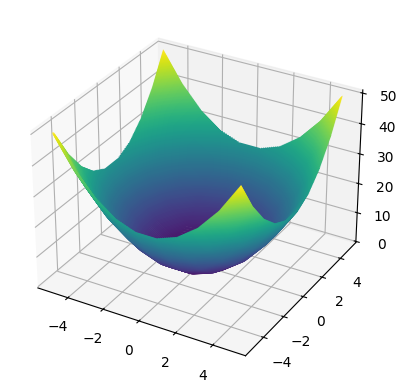

In [5]:
fig=plt.figure()
ax=fig.add_subplot(projection="3d")
ax.contour3D(i,j,scalarPotential(i,j),200)
plt.show()

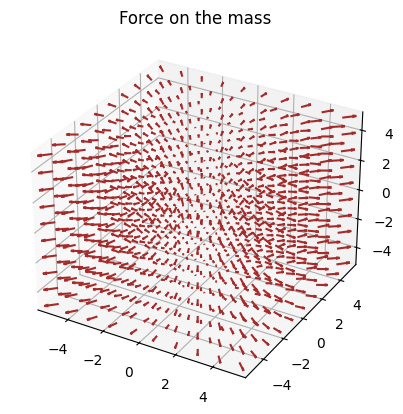

In [6]:
fig=plt.figure()
ax=fig.add_subplot(projection="3d")
ax.quiver(x,y,z,x/10,y/10,0,color="brown")
plt.title("Force on the mass")
plt.show()

We solve the following differential equation:
$$ m\ddot{\vec{r}} = -\xi\dot{\vec{r}}-\nabla U(\vec{r}) + \vec{F}_\mathrm{ext}.$$

For the profile of the bowl we consider a quadratic function
$$ U(\vec{r}) = U_0 r^2 = U_0 (x^2 + y^2). $$

The gradient is 
$$ \nabla U(\vec{r}) = 2U_0 \begin{pmatrix}x\\y\end{pmatrix} = 2U_0\vec{r}. $$

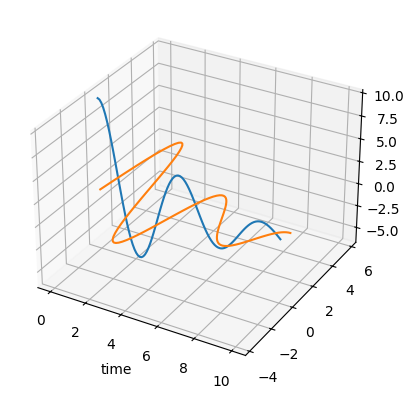

In [7]:
def Grapotential(x):
    return 2*x
zee=0.4

def diffeqn(t,X):
    x,v=X[0],X[1]
    return [v,-zee*v-Grapotential(x)]
t=np.linspace(0,10,100)
xsol=integrate.solve_ivp(diffeqn,t_span=[np.min(t),np.max(t)],y0=[10,0],t_eval=t)
ysol=integrate.solve_ivp(diffeqn,t_span=[np.min(t),np.max(t)],y0=[0,10],t_eval=t)
xt=xsol.y[0]
yt=ysol.y[0]
fig=plt.figure()
ax=fig.add_subplot(projection="3d")
ax.plot(t,0,xt)
ax.plot(t,yt,0)
plt.xlabel("time")
plt.show()

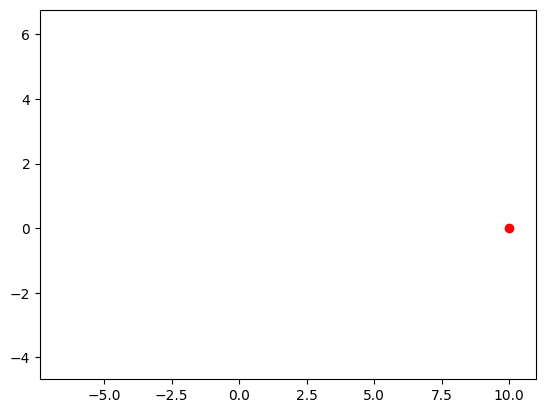

In [ ]:
fig=plt.figure()
ax=fig.add_subplot()
point, = ax.plot([], [],"ro")
ax.set_xlim(min(xt)-1, max(xt)+1)
ax.set_ylim(min(yt)-1, max(yt)+1)
def update(frame):
    point.set_data([xt[frame]], [yt[frame]])
    return point,
ani = FuncAnimation(fig, update, frames=len(t), interval=50)
ani.save("Graphs\\2DharmonicOscillator.mp4")
    